<a href="https://colab.research.google.com/github/gapalfaro-cmyk/gapalfaro-cmyk-Proyecto-de-fin-de-modulo-7.2---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Modulo7_Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modulo 7 Tarea 2

Instrucciones:
1. Identifique las covariables, el tiempo observado y el indicador de evento,
y hacer un análisis exploratorio de los datos.
2. Divida la base de datos en conjuntos de entrenamiento, validación y
prueba.
3. Ajuste los siguientes modelos utilizando la misma partición de datos:
Modelo de riesgo proporcional de Cox (clásico) y Modelo DeepSurv
uutilizando PyCox.

4. Evalúe ambos modelos sobre el conjunto de prueba mediante el C-
index.

5. Para el modelo DeepSurv presentar: gráfica de la función de pérdida en
entrenamiento y validación, y curvas de supervivencia para al menos
tres individuos.
6. Presente una tabla comparativa con el C-index de ambos modelos.

7. Escriba una conclusión breve indicando: qué modelo obtuvo mejor de-
sempeño, si DeepSurv produjo una mejora relevante frente al modelo

de Cox, y qué posibles razones explican los resultados obtenidos.

# Descripción del problema
Modelar el tiempo de supervivencia de los pacientes con cancer de mama.


# Metodología
Realizar modelos con las siguientes metodologías:

Análisis de Supervivencia
*   SGD (Cox)
*   Redes Neuronales (DeepSurv)

# Programación y Resultados (tablas y gráficas a continuación...)



In [2]:
# Se instala la librería de PyCox
!pip -q install pycox
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [43]:
# Se imporan las paqueterías necesarias

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

from scipy.stats import chi2_contingency

from matplotlib.pyplot import subplots

from ISLP.models import ModelSpec as MS
from ISLP import load_data

# Implementa DeepSurv como un caso particular del modelo CoxPH
from pycox.models import CoxPH
import torchtuples as tt
from pycox.evaluation import EvalSurv
from pycox.models import CoxPH

from sklearn.model_selection import train_test_split

In [4]:
from lifelines import \
     (KaplanMeierFitter,
      CoxPHFitter)
from lifelines.statistics import \
     (logrank_test,
      multivariate_logrank_test)
from ISLP.survival import sim_time

In [5]:
# Se sube el archivo a la pestaña de archivos en Colab y se importa
df = pd.read_csv('brca_metabric_clinical_data.tsv', sep='\t')

# Renombrar las columnas para evitar problemas con apóstrofes
#df = df.rename(columns={'Overall Survival (Months)': 'duration', 'Patient\'s Vital Status': 'event'})

df.head()

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


# EDA - Análisis de la información

Identificar las covariables, el tiempo observado y el indicador de evento, y hacer un análisis exploratorio de los datos.

Resultados (programación posterior):

1: Las covaribles son:
*   Age at Diagnosis
*   Type of Breast Surgery
*   Cancer Type Detailed
*   Cellularity
*   Chemotherapy
*   Pam50 + Claudin-low subtype
*   Cohort
*   ER status measured by IHC
*   ER Status
*   Neoplasm Histologic Grade
*   HER2 status measured by SNP6
*   HER2 Status
*   Tumor Other Histologic Subtype
*   Hormone Therapy
*   Inferred Menopausal State
*   Integrative Cluster
*   Primary Tumor Laterality
*   Lymph nodes examined positive
*   Mutation Count
*   Nottingham prognostic index
*   Oncotree Code
*   PR Status
*   Radio Therapy
*   3-Gene classifier subtype
*   TMB (nonsynonymous)
*   Tumor Size
*   Tumor Stage

2: El tiempo observado es:
*   Overall Survival (Months)+

3: El indicador del evento (muerte) es:
*   Overall Survival Status
*   Patient's Vital Status


In [6]:
# Mostrar listado de las columnas y sus características
def resumen_df(df, nombre="Metabric"):
    print(f"Resumen de {nombre}:")
    print(f"- Filas: {df.shape[0]}")
    print(f"- Columnas: {df.shape[1]}")
    display(df.info())

resumen_df(df, "brca_metabric_clinical_data")

# Mostrar las primeras filas
df.head()

Resumen de brca_metabric_clinical_data:
- Filas: 2509
- Columnas: 39
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Study ID                        2509 non-null   object 
 1   Patient ID                      2509 non-null   object 
 2   Sample ID                       2509 non-null   object 
 3   Age at Diagnosis                2498 non-null   float64
 4   Type of Breast Surgery          1955 non-null   object 
 5   Cancer Type                     2509 non-null   object 
 6   Cancer Type Detailed            2509 non-null   object 
 7   Cellularity                     1917 non-null   object 
 8   Chemotherapy                    1980 non-null   object 
 9   Pam50 + Claudin-low subtype     1980 non-null   object 
 10  Cohort                          2498 non-null   float64
 11  ER status measured by IHC 

None

,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,...,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,...,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


In [7]:
# Clasificación de columnas
num_columns = ["Age at Diagnosis", "Cohort", "Neoplasm Histologic Grade", "Lymph nodes examined positive", "Mutation Count", "Nottingham prognostic index",
               "Number of Samples Per Patient", "TMB (nonsynonymous)", "Tumor Size", "Tumor Stage" ]

categorical_columns = ["Type of Breast Surgery", "Cancer Type", "Cancer Type Detailed" , "Cellularity", "Chemotherapy", "Pam50 + Claudin-low subtype",
                       "ER status measured by IHC", "ER Status", "HER2 status measured by SNP6", "HER2 Status", "Tumor Other Histologic Subtype", "Hormone Therapy",
                       "Inferred Menopausal State", "Integrative Cluster", "Primary Tumor Laterality", "Oncotree Code", "Overall Survival Status", "PR Status",
                       "Radio Therapy", "Relapse Free Status" , "Sample Type", "Sex", "3-Gene classifier subtype", "Patient's Vital Status" ]

tiempo = ["Overall Survival (Months)"]

estatus = ["Patient\'s Vital Status"]

other_columns = ["Relapse Free Status (Months)"]

In [8]:
# Análisis de las columnas numéricas
display(df[num_columns].describe())

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Number of Samples Per Patient,TMB (nonsynonymous),Tumor Size,Tumor Stage
count,2498.000000,2498.000000,2388.000000,2243.000000,2358.000000,2287.000000,2509.0,2509.000000,2360.000000,1788.000000
mean,60.420300,2.900320,2.412060,1.950513,5.590755,4.028787,1.0,6.849746,26.220093,1.713647
std,13.032997,1.962216,0.649363,4.017774,3.989171,1.189092,0.0,5.320394,15.370883,0.655307
min,21.930000,1.000000,1.000000,0.000000,1.000000,1.000000,1.0,0.000000,1.000000,0.000000
25%,50.920000,1.000000,2.000000,0.000000,3.000000,3.048000,1.0,3.922553,17.000000,1.000000
50%,61.110000,3.000000,3.000000,0.000000,5.000000,4.044000,1.0,6.537589,22.410000,2.000000
75%,70.000000,4.000000,3.000000,2.000000,7.000000,5.040000,1.0,9.152624,30.000000,2.000000
max,96.290000,9.000000,3.000000,45.000000,81.000000,7.200000,1.0,104.601416,182.000000,4.000000


In [9]:
# Valores de las columnas categóricas

for i in categorical_columns:
    print("Columna: ", i)
    display(df[i].unique())
    print("\n")

Columna:  Type of Breast Surgery


array(['MASTECTOMY', 'BREAST CONSERVING', nan], dtype=object)



Columna:  Cancer Type


array(['Breast Cancer'], dtype=object)



Columna:  Cancer Type Detailed


...

array(['Female'], dtype=object)



Columna:  3-Gene classifier subtype


array(['ER-/HER2-', 'ER+/HER2- High Prolif', nan, 'ER+/HER2- Low Prolif',
       'HER2+'], dtype=object)



Columna:  Patient's Vital Status


array(['Living', 'Died of Disease', 'Died of Other Causes', nan],
      dtype=object)

In [10]:
# Matriz de correlación entre variables categóricas definidas arriba

# Definir función Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))

# Crear matriz vacía
results = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# Calcular Cramer's V entre todas las combinaciones
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 == col2:
            results.loc[col1,col2] = 1.0
        else:
            results.loc[col1,col2] = cramers_v(df[col1], df[col2])

print(results)

/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(p

                               Type of Breast Surgery Cancer Type  \
Type of Breast Surgery                            1.0         NaN   
Cancer Type                                       NaN         1.0   
Cancer Type Detailed                              0.0         NaN   
Cellularity                                  0.018731         NaN   
Chemotherapy                                 0.041494         NaN   
Pam50 + Claudin-low subtype                  0.105224         NaN   
ER status measured by IHC                         0.0         NaN   
ER Status                                         0.0         NaN   
HER2 status measured by SNP6                  0.07888         NaN   
HER2 Status                                  0.061798         NaN   
Tumor Other Histologic Subtype               0.053457         NaN   
Hormone Therapy                                   0.0         NaN   
Inferred Menopausal State                    0.038352         NaN   
Integrative Cluster               

/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))
/tmp/ipykernel_493/32051597.py:13: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))


# Modelos

In [11]:
# Transformar la variable Patient's Vital Status en numérica
# Ref: Columna:  Overall Survival Status
#array(['0:LIVING', '1:DECEASED', nan], dtype=object)
status_map0 = {
    "0:LIVING": 0,
    "1:DECEASED": 1
}

status_map = {
    "Living": 0,
    "Died of Disease": 1,
    "Died of Other Causes": 2
}

# Aplicamos el mapeo
df["Overall Survival Status"] = df["Overall Survival Status"].map(status_map0)
df["Patient\'s Vital Status"] = df["Patient\'s Vital Status"].map(status_map)

# Si quieres convertir NaN en un valor específico (ej. -1)
# df["Patient's Vital Status"] = df["Patient's Vital Status"].fillna(-1)

# Aseguramos que sea tipo numérico
df["Overall Survival Status"] = df["Overall Survival Status"].astype("float64")
df["Patient\'s Vital Status"] = df["Patient\'s Vital Status"].astype("float64")

print(df["Overall Survival Status"].unique())
print(df["Patient\'s Vital Status"].unique())

[ 0.  1. nan]
[ 0.  1.  2. nan]


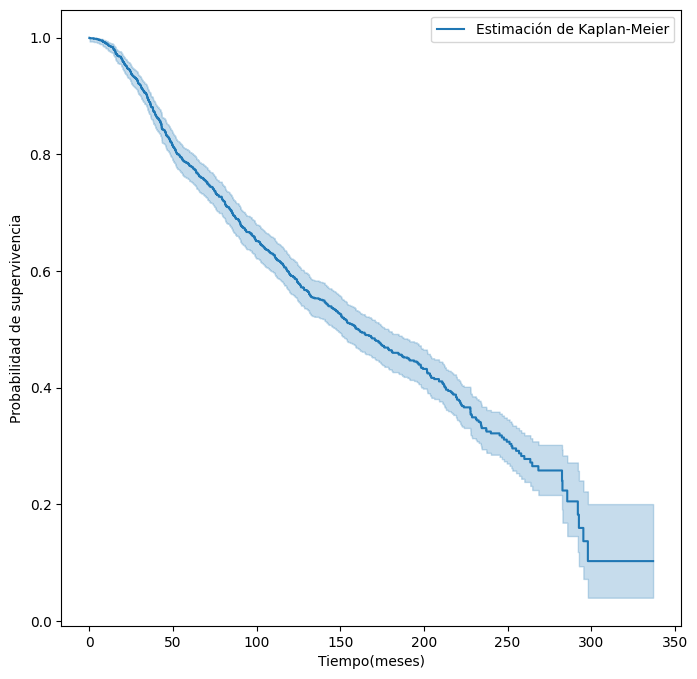

In [12]:
df_nonull=df.dropna()

# Grafica la curva de supervivencia de Kaplan-Meier
fig, ax=subplots(figsize=(8,8))
km=KaplanMeierFitter()
km_mama=km.fit(df_nonull['Overall Survival (Months)'],df_nonull['Overall Survival Status'])
km_mama.plot(label='Estimación de Kaplan-Meier', ax=ax)
ax.set_xlabel('Tiempo(meses)')
ax.set_ylabel('Probabilidad de supervivencia')
ax.legend()

2. Divida la base de datos en conjuntos de entrenamiento, validación y
prueba.

In [45]:
# Primero dividimos en entrenamiento y (validación+prueba)
train_df, temp_df = train_test_split(df_nonull, test_size=0.4, random_state=42)

# Luego dividimos temp_df en validación y prueba
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Tamaño entrenamiento:", len(train_df))
print("Tamaño validación:", len(val_df))
print("Tamaño prueba:", len(test_df))

Tamaño entrenamiento: 655
Tamaño validación: 218
Tamaño prueba: 219


3. Ajuste los siguientes modelos utilizando la misma partición de datos: Modelo de riesgo proporcional de Cox (clásico) y Modelo DeepSurv utilizando PyCox.

In [47]:
coxph=CoxPHFitter

# Selección de variables clínicas
covariables = [
    "Age at Diagnosis", #3 rango 21-96
    "Tumor Size", #36 rango 1-182
    "Neoplasm Histologic Grade", #13 "Histological Grade" valores 1-3
    "Lymph nodes examined positive", #21 valores 0-45
    "ER Status", #12 array(['Positve', 'Negative', nan], dtype=object)
    "HER2 Status", #15 array(['Negative', nan, 'Positive'], dtype=object)
    "Chemotherapy", #8 array(['NO', 'YES', nan], dtype=object)
    "Hormone Therapy" #17 array(['YES', 'NO', nan], dtype=object)
]

# Codificar variables categóricas en dummies
train_df_encoded = pd.get_dummies(train_df[covariables], drop_first=True)

# Construir DataFrame para Cox - ya habíamos creado las variables "status_map0" y "status_map" pero para que esté autocontenido
cox_train_df = pd.concat([
    train_df[["Overall Survival (Months)", "Overall Survival Status"]],
    train_df_encoded
], axis=1).dropna()

all_MS = MS(cox_train_df.columns, intercept=False)
train_ms_df = all_MS.fit_transform(cox_train_df)

# Instanciar y Entrenar el modelo de Cox
cox_model = CoxPHFitter(penalizer=0.01)
fit_all = cox_model.fit(
    train_ms_df,
    duration_col='Overall Survival (Months)',
    event_col='Overall Survival Status'
)

# Mostrar el resumen estadístico
print(fit_all.summary[['coef', 'se(coef)', 'p']])

                                   coef  se(coef)             p
covariate                                                      
Age at Diagnosis               0.044718  0.005179  5.868610e-18
Tumor Size                     0.009093  0.002606  4.848035e-04
Neoplasm Histologic Grade      0.086599  0.092333  3.482995e-01
Lymph nodes examined positive  0.048001  0.013694  4.561407e-04
ER Status_Positive            -0.184874  0.156365  2.370764e-01
HER2 Status_Positive           0.450604  0.175119  1.007836e-02
Chemotherapy_YES               0.334995  0.173299  5.323093e-02
Hormone Therapy_YES           -0.006203  0.122369  9.595737e-01


4. Evalúe modelo Cox sobre el conjunto de prueba mediante el C-index.


In [49]:
# Predicciones en test

# Codificar variables categóricas en dummies
test_df_encoded = pd.get_dummies(test_df[covariables], drop_first=True)
# Reindexar para asegurar que test tenga las mismas columnas dummies que train
test_df_encoded = test_df_encoded.reindex(columns=train_df_encoded.columns, fill_value=0)

cox_test_df = pd.concat([
    test_df[["Overall Survival (Months)", "Overall Survival Status"]],
    test_df_encoded
], axis=1).dropna()

test_ms_df = all_MS.transform(cox_test_df) # Transformar test con el mismo fit de train

# Predicciones sobre el conjunto de PRUEBA (usando la instancia entrenada 'fit_all')
pred_partial_hazards = fit_all.predict_partial_hazard(test_ms_df)

# 7. Calcular el C-index en Test
c_index_cox = concordance_index(
    event_times=test_ms_df["Overall Survival (Months)"],
    predicted_scores=-pred_partial_hazards,  # Signo negativo: mayor riesgo = menor tiempo esperado
    event_observed=test_ms_df["Overall Survival Status"]
)

print("\n----------------------------------")
print(f"C-index Cox (Conjunto de Prueba): {c_index_cox:.4f}")
print("----------------------------------")



----------------------------------
C-index Cox (Conjunto de Prueba): 0.6345
----------------------------------


DeepSurv (pycox) - modelo de redes neuronales

In [56]:
# Duración y evento
durations = train_df["Overall Survival (Months)"].values.astype('float32')
events = train_df["Overall Survival Status"].values.astype('int64')

# Normalizar covariables
x_train = (train_df_encoded - train_df_encoded.mean()) / train_df_encoded.std()
x_values = x_train.values.astype('float32')

# Definir red neuronal para DeepSurv
in_features = x_values.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features,
                              batch_norm, dropout)

model = CoxPH(net, tt.optim.Adam)

# Configurar tasa de aprendizaje (Learning Rate)
model.optimizer.set_lr(0.01)

# Entrenar modelo
log = model.fit(x_values, (durations, events),
          batch_size=128,
          epochs=100,
          verbose=True)

_ = model.compute_baseline_hazards()

0:	[0s / 0s],		train_loss: 3.7989
1:	[0s / 0s],		train_loss: 3.6747
2:	[0s / 0s],		train_loss: 3.6139
3:	[0s / 0s],		train_loss: 3.6852
4:	[0s / 0s],		train_loss: 3.6530
5:	[0s / 0s],		train_loss: 3.6718
6:	[0s / 0s],		train_loss: 3.6526
7:	[0s / 0s],		train_loss: 3.7350
8:	[0s / 0s],		train_loss: 3.6163
9:	[0s / 0s],		train_loss: 3.6041
10:	[0s / 0s],		train_loss: 3.6045
11:	[0s / 0s],		train_loss: 3.6277
12:	[0s / 0s],		train_loss: 3.6120
13:	[0s / 0s],		train_loss: 3.5569
14:	[0s / 0s],		train_loss: 3.6872
15:	[0s / 0s],		train_loss: 3.5599
16:	[0s / 0s],		train_loss: 3.5998
17:	[0s / 0s],		train_loss: 3.5588
18:	[0s / 0s],		train_loss: 3.6983
19:	[0s / 0s],		train_loss: 3.5302
20:	[0s / 0s],		train_loss: 3.6132
21:	[0s / 0s],		train_loss: 3.6090
22:	[0s / 0s],		train_loss: 3.5723
23:	[0s / 0s],		train_loss: 3.5411
24:	[0s / 0s],		train_loss: 3.5226
25:	[0s / 0s],		train_loss: 3.5602
26:	[0s / 0s],		train_loss: 3.5478
27:	[0s / 0s],		train_loss: 3.5915
28:	[0s / 0s],		train_loss: 3.

4. Evalúe modelo DeepSurv sobre el conjunto de prueba mediante el C-index.

In [54]:
# Predicciones en test


# Preprocesar test_df con las mismas transformaciones (dummies y normalización de train)
test_df_encoded = pd.get_dummies(test_df[covariables], drop_first=True)
test_df_encoded = test_df_encoded.reindex(columns=train_df_encoded.columns, fill_value=0)

# Normalizar test_df usando la media y desviación estándar de train (Evita Data Leakage)
x_test = (test_df_encoded - train_df_encoded.mean()) / train_df_encoded.std()
x_test_values = x_test.values.astype('float32')

durations_test = test_df["Overall Survival (Months)"].values.astype('float32')
events_test = test_df["Overall Survival Status"].values.astype('int64')

# Predecir curvas de supervivencia en Test
surv_test = model.predict_surv_df(x_test_values)

# Calcular C-index en Test
ev_test = EvalSurv(surv_test, durations_test, events_test, censor_surv='km')
print("\n----------------------------------")
print(f"C-index DeepSurv (Conjunto de Prueba): {ev_test.concordance_td():.4f}")
print("----------------------------------")


----------------------------------
C-index DeepSurv (Conjunto de Prueba): 0.6338
----------------------------------


5. Para el modelo DeepSurv presentar: gráfica de la función de pérdida en
entrenamiento y validación, y curvas de supervivencia para al menos
tres individuos.

<Figure size 1000x500 with 0 Axes>

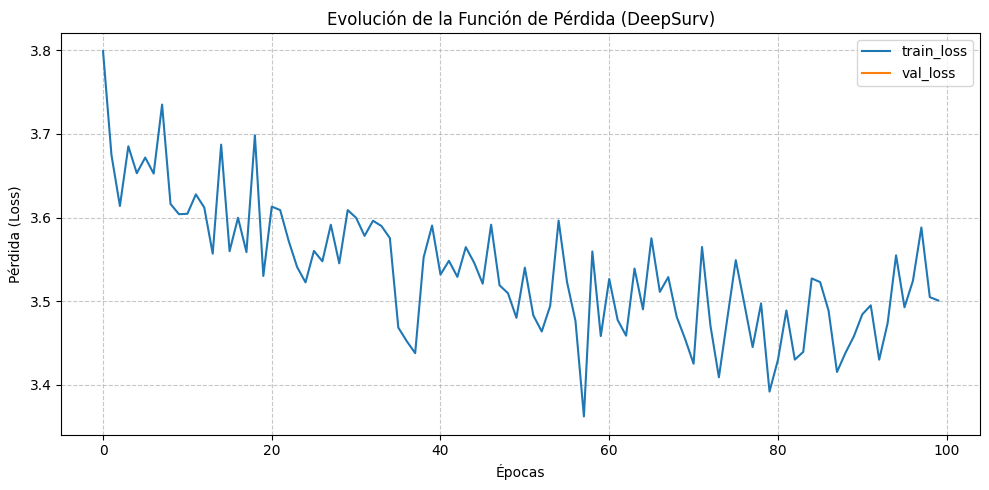

In [57]:
# Gráfica de la función de pérdida (Train vs Val)
# Se guardó el modelo: log = model.fit(x_values, (durations, events),batch_size=128,epochs=100,verbose=True)

plt.figure(figsize=(10, 5))
# El objeto log de pycox/torchtuples tiene un método to_pandas()
_ = log.to_pandas()[['train_loss', 'val_loss']].plot(figsize=(10, 5))

plt.title('Evolución de la Función de Pérdida (DeepSurv)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

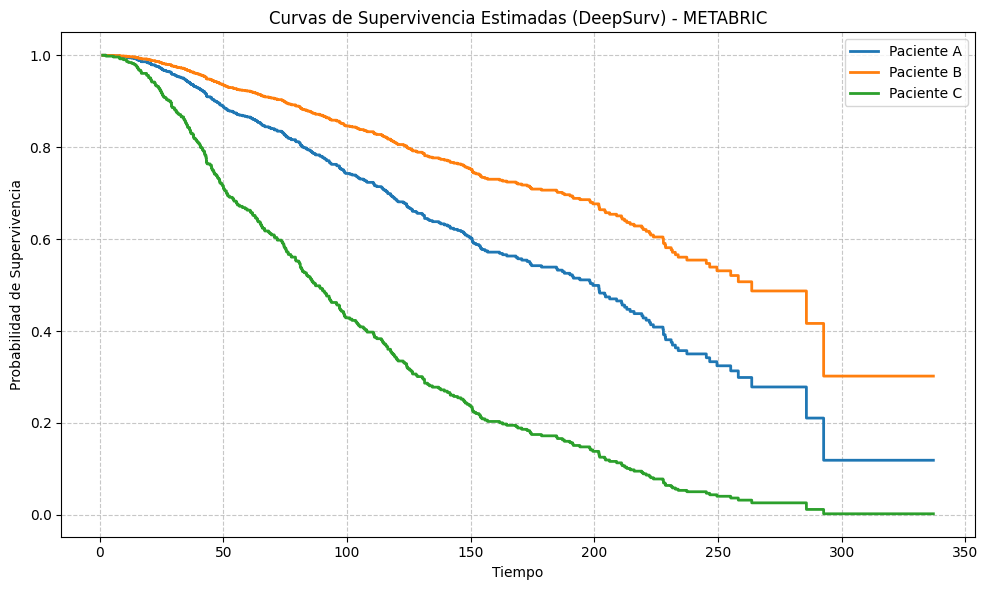

In [59]:
# Curvas de supervivencia para 3 individuos

# Seleccionamos a los primeros 3 pacientes del conjunto de test
# (Asegúrate de que X_test sea un numpy array de tipo float32, como lo requiere pycox)
X_sample = x_test_values[0:3]

# Generamos el DataFrame con las curvas de supervivencia
# El índice será el tiempo y cada columna será un paciente
surv_curves = model.predict_surv_df(X_sample)

plt.figure(figsize=(10, 6))
# drawstyle='steps-post' es el estándar para curvas de supervivencia (tipo Kaplan-Meier)
surv_curves.plot(drawstyle='steps-post', figsize=(10, 6), linewidth=2)

plt.title('Curvas de Supervivencia Estimadas (DeepSurv) - METABRIC')
plt.xlabel('Tiempo')
plt.ylabel('Probabilidad de Supervivencia')
plt.legend(['Paciente A', 'Paciente B', 'Paciente C'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

6. Presente una tabla comparativa con el C-index de ambos modelos.


In [63]:
from tabulate import tabulate

# variables de los C-index en el conjunto de test de ambos modelos
c_index_cox_val = c_index_cox                       # C-index CoxPHFitter
c_index_deepsurv_val = ev_test.concordance_td()     # C-index PyCox / EvalSurv

# Creación del DataFrame Comparativo
df_comparativa = pd.DataFrame({
    'Modelo': [
        'Riesgo Proporcional de Cox',
        'DeepSurv (PyCox)'
    ],
    'Arquitectura': [
        'Semiparamétrico Lineal (Log-hazard)',
        'Red Neuronal Profunda (MLP + Cox Loss)'
    ],
    'Métrica de Evaluación': [
        'Harrell / Time-Dependent C-index',
        'Time-Dependent C-index'
    ],
    'C-Index (Conjunto de Prueba)': [
        c_index_cox_val,
        c_index_deepsurv_val
    ]
})

# Imprimir Tabla en Formato Consola / Texto Plano

print("\n--- TABLA COMPARATIVA DE RESULTADOS ---")
print(tabulate(
    df_comparativa,
    headers='keys',
    tablefmt='fancy_grid',
    showindex=False,
    floatfmt=".4f"
))



--- TABLA COMPARATIVA DE RESULTADOS ---
╒════════════════════════════╤════════════════════════════════════════╤══════════════════════════════════╤════════════════════════════════╕
│ Modelo                     │ Arquitectura                           │ Métrica de Evaluación            │   C-Index (Conjunto de Prueba) │
╞════════════════════════════╪════════════════════════════════════════╪══════════════════════════════════╪════════════════════════════════╡
│ Riesgo Proporcional de Cox │ Semiparamétrico Lineal (Log-hazard)    │ Harrell / Time-Dependent C-index │                         0.6345 │
├────────────────────────────┼────────────────────────────────────────┼──────────────────────────────────┼────────────────────────────────┤
│ DeepSurv (PyCox)           │ Red Neuronal Profunda (MLP + Cox Loss) │ Time-Dependent C-index           │                         0.6338 │
╘════════════════════════════╧════════════════════════════════════════╧══════════════════════════════════╧═════════════

# Conclusiones

1. El modelo con mejor desempeño fue Cox, sin embargo la diferencia en resultados entre ambos modelos es mínima.


2. El modelo de DeepSurv no presentó una mejora frente al modelo de Cox utilizando las mismas variables; sin embargo, podría tener mejores resultados si se aumentaran las variables.

3. Posibles razones son que no se utilizaron más variables en el modelo de DeepSurv limitando sus capacidades computacionales


# Aquí intentamos correr el modelo con más variables... pero no nos salió a tiempo.... CASO 2

In [78]:
# Selección de variables... IMPORTANTE HACER UN FILTRO DEJANDO COVARIABLES CON VARIANZA Y DEJANDO LA MAYOR CANTIDAD DE REGISTROS
covariables = ["Age at Diagnosis", "Cohort", "Neoplasm Histologic Grade", "Lymph nodes examined positive", "Mutation Count", "Nottingham prognostic index",
               "Number of Samples Per Patient", "TMB (nonsynonymous)", "Tumor Size", "Tumor Stage", "Type of Breast Surgery",  "Cancer Type Detailed" , "Cellularity", "Chemotherapy",
                       "ER status measured by IHC", "ER Status", "HER2 status measured by SNP6", "HER2 Status", "Tumor Other Histologic Subtype", "Hormone Therapy",
                       "Inferred Menopausal State", "Integrative Cluster", "Primary Tumor Laterality", "Oncotree Code", "PR Status",
                       "Radio Therapy", "3-Gene classifier subtype"
                       ]

In [79]:
# Duración y evento
train_df_na = train_df.dropna()

durations = train_df_na["Overall Survival (Months)"].values.astype('float32')
events = train_df_na["Overall Survival Status"].values.astype('int64')

# Codificar variables categóricas en dummies
train_df_encoded = pd.get_dummies(train_df_na[covariables], drop_first=True)

# Normalizar covariables
x_train = (train_df_encoded - train_df_encoded.mean()) / train_df_encoded.std()
x_values = x_train.values.astype('float32')

# Definir red neuronal para DeepSurv
in_features = x_values.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features,
                              batch_norm, dropout)

model = CoxPH(net, tt.optim.Adam)

# Configurar tasa de aprendizaje (Learning Rate)
model.optimizer.set_lr(0.01)

# Entrenar modelo
log = model.fit(x_values, (durations, events),
          batch_size=128,
          epochs=100,
          verbose=True)

_ = model.compute_baseline_hazards()

0:	[0s / 0s],	
1:	[0s / 0s],	
2:	[0s / 0s],	
3:	[0s / 0s],	
4:	[0s / 0s],	
5:	[0s / 0s],	
6:	[0s / 0s],	
7:	[0s / 0s],	
8:	[0s / 0s],	
9:	[0s / 0s],	
10:	[0s / 0s],	
11:	[0s / 0s],	
12:	[0s / 0s],	
13:	[0s / 0s],	
14:	[0s / 0s],	
15:	[0s / 0s],	
16:	[0s / 0s],	
17:	[0s / 0s],	
18:	[0s / 0s],	
19:	[0s / 0s],	
20:	[0s / 0s],	
21:	[0s / 0s],	
22:	[0s / 0s],	
23:	[0s / 0s],	
24:	[0s / 0s],	
25:	[0s / 0s],	
26:	[0s / 0s],	
27:	[0s / 0s],	
28:	[0s / 0s],	
29:	[0s / 0s],	
30:	[0s / 0s],	
31:	[0s / 0s],	
32:	[0s / 0s],	
33:	[0s / 0s],	
34:	[0s / 0s],	
35:	[0s / 0s],	
36:	[0s / 0s],	
37:	[0s / 0s],	
38:	[0s / 0s],	
39:	[0s / 0s],	
40:	[0s / 0s],	
41:	[0s / 0s],	
42:	[0s / 0s],	
43:	[0s / 0s],	
44:	[0s / 0s],	
45:	[0s / 0s],	
46:	[0s / 0s],	
47:	[0s / 0s],	
48:	[0s / 0s],	
49:	[0s / 0s],	
50:	[0s / 0s],	
51:	[0s / 0s],	
52:	[0s / 0s],	
53:	[0s / 0s],	
54:	[0s / 0s],	
55:	[0s / 0s],	
56:	[0s / 0s],	
57:	[0s / 0s],	
58:	[0s / 0s],	
59:	[0s / 0s],	
60:	[0s / 0s],	
61:	[0s / 0s],	
62:	[0s / 0s],	
63